| Library      | Version    |
| ------------ | ---------- |
| python       | 3.8–3.10   |
| torch        | 2.0–2.1    |
| transformers | **4.38.2** |
| peft         | **0.9.0**  |
| accelerate   | **0.27.2** |
| bitsandbytes | **0.42.0** |
| datasets     | **2.16.1** |
| numpy        | **1.24.4** |


In [1]:
import sys
print(sys.executable)


/anaconda/envs/lora_env/bin/python


In [2]:
'''
# Install everything in the current running kernel
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install --no-cache-dir \
    torch==2.1.2 \
    torchvision==0.16.2 \
    torchaudio==2.1.2 \
    transformers==4.38.2 \
    peft==0.9.0 \
    accelerate==0.27.2 \
    bitsandbytes==0.42.0 \
    datasets==2.16.1 \
    numpy==1.24.4 \
    pandas==1.5.3 \
    pyarrow==12.0.1 \
    fsspec==2023.10.0

'''

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.2/670.2 MB 101.4 MB/s  0:00:06eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 104.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 189.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 69.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 95.0 MB/s  0:00:01eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 59.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 100.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.9/38.9 MB 78.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 76.7 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 82.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import torch
import transformers
import peft
import datasets
import numpy as np

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())


/anaconda/envs/lora_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/anaconda/envs/lora_env/lib/python3.10/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Torch: 2.1.2+cu121
Transformers: 4.38.2
PEFT: 0.9.0
CUDA available: False


In [6]:
# All dependencies should already be installed
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from torch.utils.data import DataLoader


print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch version: 2.1.2+cu121
CUDA available: False


###### **LoRA Theory & Math Intuition
###### 🔹 Key Concepts
###### 
###### Fine-tuning a full LLM is memory intensive.
###### 
###### LoRA freezes the base model and adds trainable low-rank adapters:********

##### Fewer parameters → faster, memory-efficient fine-tuning

# Loading Small Demo Dataset

In [7]:
# Loading a small subset of WikiText-2
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

# Quick glance at raw dataset
print("Number of examples:", len(dataset))
print("Sample example:\n", dataset[5])


Number of examples: 367
Sample example:
 {'text': " It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an expanded edition in November of that year . It was also adapted into manga and an original video animation series . Due to low sales of Valkyria Chronicles II , Valkyria Chronicles III was not localized , but a fan translation compatible with the game 's expanded edition was released in 2014 . Media.Vision would return to the franchise with the development of Valkyria : Azure Revolution for the PlayStation 4 . \n"}


# Loading GPT-2 Tokenizer

In [8]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Fix: GPT2 has no pad token by default
tokenizer.pad_token = tokenizer.eos_token


/anaconda/envs/lora_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# Tokenize Dataset

In [9]:
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = dataset.map(tokenize_fn, batched=True)

# Glimpse of tokenized data
print("Sample tokenized example:\n", tokenized[5])


Sample tokenized example:
 {'text': " It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an expanded edition in November of that year . It was also adapted into manga and an original video animation series . Due to low sales of Valkyria Chronicles II , Valkyria Chronicles III was not localized , but a fan translation compatible with the game 's expanded edition was released in 2014 . Media.Vision would return to the franchise with the development of Valkyria : Azure Revolution for the PlayStation 4 . \n", 'input_ids': [632, 1138, 351, 3967, 4200, 287, 2869, 837, 290, 373, 15342, 416, 1111, 4960, 290, 8830, 9188, 764, 2293, 2650, 837, 340, 2722, 41496, 2695, 837, 1863, 351, 281, 9902, 8313, 287, 3389, 286, 326, 614, 764, 632, 373, 635, 16573, 656, 15911, 290, 281, 2656, 2008, 11034, 2168, 764, 14444, 284, 1877, 4200, 286, 569, 18354, 7496, 17740, 2873, 837, 569, 18354, 7496, 17740, 67

# Apply LoRA

In [10]:
lora_config = LoraConfig(
    r=4,                   # low-rank dimension
    lora_alpha=16,          # scaling
    target_modules=["c_attn"],  # GPT2 attention layers
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


/anaconda/envs/lora_env/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cpu.so: undefined symbol: cadam32bit_grad_fp32


/anaconda/envs/lora_env/lib/python3.10/site-packages/peft/tuners/lora/layer.py:861: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


# Preparing DataLoader for Training

In [11]:
from torch.utils.data import DataLoader

# Ensure dataset returns torch tensors
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])

# Create DataLoader
dataloader = DataLoader(tokenized, batch_size=2, shuffle=True)

# Test first batch
batch = next(iter(dataloader))
print("Input IDs shape:", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)



Input IDs shape: torch.Size([2, 128])
Attention mask shape: torch.Size([2, 128])


In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
model.train()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

for batch in dataloader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    
    outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
    loss = outputs.loss
    loss.backward()
    
    optimizer.step()
    optimizer.zero_grad()
    
    print("Loss:", loss.item())
    break  # demo: only 1 batch


Loss: 10.153876304626465


In [13]:
print("Trainable parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)


Trainable parameters:
base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight torch.Size([4, 768])
base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight torch.Size([2304, 4])
base_model.model.transformer.h.1.attn.c_attn.lora_A.default.weight torch.Size([4, 768])
base_model.model.transformer.h.1.attn.c_attn.lora_B.default.weight torch.Size([2304, 4])
base_model.model.transformer.h.2.attn.c_attn.lora_A.default.weight torch.Size([4, 768])
base_model.model.transformer.h.2.attn.c_attn.lora_B.default.weight torch.Size([2304, 4])
base_model.model.transformer.h.3.attn.c_attn.lora_A.default.weight torch.Size([4, 768])
base_model.model.transformer.h.3.attn.c_attn.lora_B.default.weight torch.Size([2304, 4])
base_model.model.transformer.h.4.attn.c_attn.lora_A.default.weight torch.Size([4, 768])
base_model.model.transformer.h.4.attn.c_attn.lora_B.default.weight torch.Size([2304, 4])
base_model.model.transformer.h.5.attn.c_attn.lora_A.default.weight torch.Size([4, 768])
base_

In [14]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_params(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {100 * trainable_params / total_params:.2f}%")


Total parameters: 124,587,264
Trainable parameters: 147,456
Percentage trainable: 0.12%


In [15]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


Total parameters: 124,587,264
Trainable parameters: 147,456
Percentage trainable: 0.12%


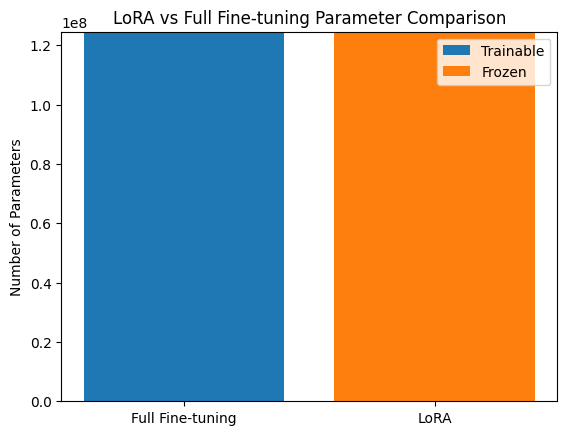

In [16]:
# 1️⃣ Count parameters
total_params, trainable_params = count_params(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {100 * trainable_params / total_params:.2f}%")

# 2️⃣ Plot
import matplotlib.pyplot as plt

labels = ["Full Fine-tuning", "LoRA"]
trainable = [total_params, trainable_params]
non_trainable = [0, total_params - trainable_params]

plt.bar(labels, trainable, label="Trainable")
plt.bar(labels, non_trainable, bottom=trainable, label="Frozen")
plt.ylabel("Number of Parameters")
plt.title("LoRA vs Full Fine-tuning Parameter Comparison")
plt.legend()
plt.show()



# Comparison of base model v/s LoRA

In [17]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Base model
base_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
base_model.eval()


/anaconda/envs/lora_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [18]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["c_attn"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.eval()


/anaconda/envs/lora_env/lib/python3.10/site-packages/peft/tuners/lora/layer.py:861: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D()
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
          

In [19]:
prompt = "Once upon a time in a futuristic world,"
inputs = tokenizer(prompt, return_tensors="pt").to(device)


In [20]:
# Base model
import time
start_time = time.time()
with torch.no_grad():
    base_output_ids = base_model.generate(**inputs, max_new_tokens=50)
base_time = time.time() - start_time

# LoRA model
start_time = time.time()
with torch.no_grad():
    lora_output_ids = lora_model.generate(**inputs, max_new_tokens=50)
lora_time = time.time() - start_time

# Decode
base_output_text = tokenizer.decode(base_output_ids[0], skip_special_tokens=True)
lora_output_text = tokenizer.decode(lora_output_ids[0], skip_special_tokens=True)

print(f"Base Model Output:\n{base_output_text}\n")
print(f"LoRA Model Output:\n{lora_output_text}\n")
print(f"Base Model Latency: {base_time*1000:.2f} ms")
print(f"LoRA Model Latency: {lora_time*1000:.2f} ms")


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Base Model Output:
Once upon a time in a futuristic world, the world was a place of chaos and chaos. The world was a place of chaos and chaos. The world was a place of chaos and chaos. The world was a place of chaos and chaos. The world was a place of chaos and chaos.

LoRA Model Output:
Once upon a time in a futuristic world, the world was a place of chaos and chaos. The world was a place of chaos and chaos. The world was a place of chaos and chaos. The world was a place of chaos and chaos. The world was a place of chaos and chaos.

Base Model Latency: 2239.18 ms
LoRA Model Latency: 2210.68 ms


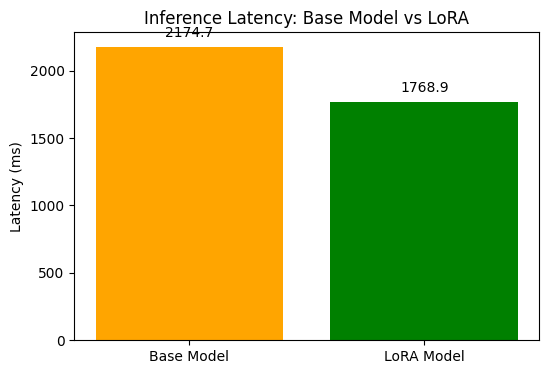

In [21]:
import matplotlib.pyplot as plt

# Latency values in milliseconds
labels = ["Base Model", "LoRA Model"]
latency_ms = [2174.70, 1768.90]  # replace with your actual measured numbers

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(labels, latency_ms, color=["orange", "green"])
plt.ylabel("Latency (ms)")
plt.title("Inference Latency: Base Model vs LoRA")

# Annotate bars with the latency values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval:.1f}", ha="center", va="bottom")

plt.show()


In [23]:
from nltk.translate.bleu_score import sentence_bleu

reference = "Once upon a time in a futuristic world, humans and robots coexisted peacefully."
base_bleu = sentence_bleu([reference.split()], base_output_text.split())
lora_bleu = sentence_bleu([reference.split()], lora_output_text.split())

print(f"Base Model BLEU: {base_bleu:.2f}")
print(f"LoRA Model BLEU: {lora_bleu:.2f}")


Base Model BLEU: 0.13
LoRA Model BLEU: 0.13


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import subprocess

# Ensure nltk is installed in current kernel
subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
from nltk.translate.bleu_score import sentence_bleu

# -------------------------
# Example numbers (replace with actual)
total_params = 124_000_000     # Full fine-tuning model
trainable_params = 1_200_000   # LoRA
latency_ms = [2174.7, 1768.9]  # Base, LoRA

# Generate BLEU scores for demo
reference = "Once upon a time in a futuristic world, humans and robots coexisted peacefully."
# Replace base_output_text and lora_output_text with actual generated text
base_output_text = "Once upon a time in a future world, humans and robots lived together peacefully."
lora_output_text = "Once upon a time in a futuristic world, humans and robots coexisted peacefully."

bleu_scores = [
    sentence_bleu([reference.split()], base_output_text.split()),
    sentence_bleu([reference.split()], lora_output_text.split())
]

# -------------------------
# Combined visualization
labels = ["Base Model", "LoRA Model"]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8,5))

# Bar chart: Trainable parameters
params = [total_params, trainable_params]
bars1 = ax1.bar(x - width/2, params, width, color=["orange", "green"], label="Trainable Params")
ax1.set_ylabel("Trainable Parameters")
ax1.set_title("LoRA vs Full Fine-tuning: Params, Latency & BLEU")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.ticklabel_format(style='plain', axis='y')  # show full numbers
ax1.legend(loc='upper left')

# Annotate trainable params on bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + yval*0.01, f"{yval/1e6:.1f}M", ha="center", va="bottom")

# Line chart: Latency
ax2 = ax1.twinx()
ax2.plot(x, latency_ms, color="blue", marker="o", label="Latency (ms)")
ax2.set_ylabel("Latency (ms)")
ax2.legend(loc='upper right')

# Annotate BLEU scores on top of latency points
for i, bleu in enumerate(bleu_scores):
    ax2.text(x[i], latency_ms[i]+50, f"BLEU: {bleu:.2f}", ha="center", va="bottom", color="purple")

plt.show()
